Step - 1 : Import Libraries

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

Step-2: Load Dataset

In [5]:
df = pd.read_csv("../data/DisasterDeclarations.csv")

df.head()

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,0,0,...,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,0,0,...,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,0,0,...,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,0,0,...,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",0,0,...,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


Step - 3:Validate Data

In [6]:
df['state'].unique()
df['state'].isnull().sum()

np.int64(0)

Step - 4: State-Level Aggregation

In [7]:
state_counts = df['state'].value_counts()

state_counts.head()

state
TX    5388
KY    3355
MO    2830
FL    2791
GA    2765
Name: count, dtype: int64

Step -5: Visualization 1:
Top 10 Disaster-Prone States

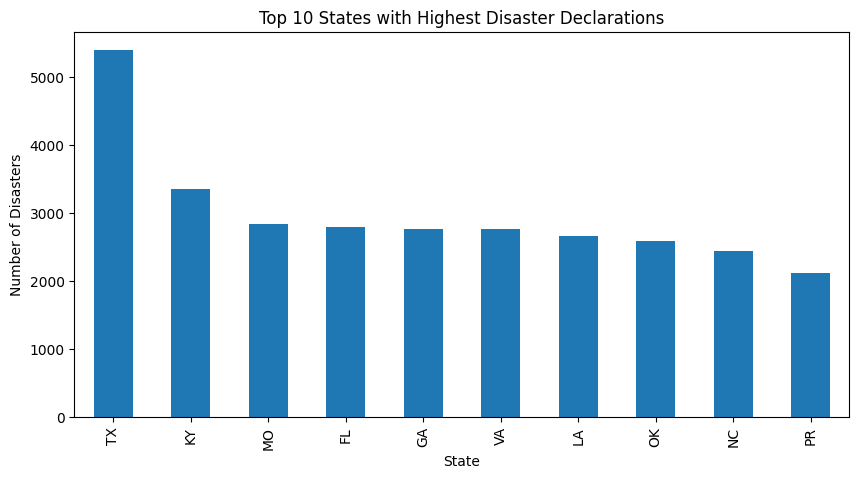

In [8]:
plt.figure(figsize=(10,5))

state_counts.head(10).plot(kind='bar')

plt.title("Top 10 States with Highest Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")

plt.show()

Insight:

Observation:
The chart shows the states with the highest number of disaster declarations.

Pattern:
States like Texas, California, and Florida have the highest counts.

Reason:
These states are more exposed to hurricanes, wildfires, and floods.

Step - :6 Choropleth Map

In [9]:
state_df = state_counts.reset_index()
state_df.columns = ['state', 'count']

fig = px.choropleth(
    state_df,
    locations='state',
    locationmode="USA-states",
    color='count',
    scope="usa",
    color_continuous_scale="Reds",
    title="Disaster Declarations by State"
)

fig.show()

Insight:

Observation:
The choropleth map shows disaster distribution across US states.

Pattern:
Southern and coastal states show higher disaster density.

Reason:
These regions are more vulnerable to hurricanes, floods, and storms.

Step - 7: State + Incident Type Analysis

In [12]:
state_incident = df.groupby(['state','incidentType']).size().unstack().fillna(0)

state_incident.head()

incidentType,Biological,Chemical,Coastal Storm,Dam/Levee Break,Drought,Earthquake,Fire,Fishing Losses,Flood,Freezing,...,Straight-Line Winds,Terrorist,Tornado,Toxic Substances,Tropical Depression,Tropical Storm,Tsunami,Typhoon,Volcanic Eruption,Winter Storm
state,,,,,,,,,,,,,,,,,,,,,
AK,121.0,0.0,2.0,0.0,0.0,13.0,35.0,0.0,71.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AL,139.0,0.0,0.0,0.0,67.0,0.0,11.0,0.0,104.0,0.0,...,0.0,0.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AR,152.0,0.0,0.0,0.0,32.0,0.0,0.0,0.0,312.0,0.0,...,0.0,0.0,113.0,0.0,0.0,0.0,0.0,0.0,0.0,88.0
AS,10.0,0.0,0.0,0.0,5.0,5.0,0.0,0.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,0.0,0.0
AZ,73.0,0.0,0.0,0.0,8.0,0.0,97.0,0.0,83.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Step - 7: Stacked Bar Chart

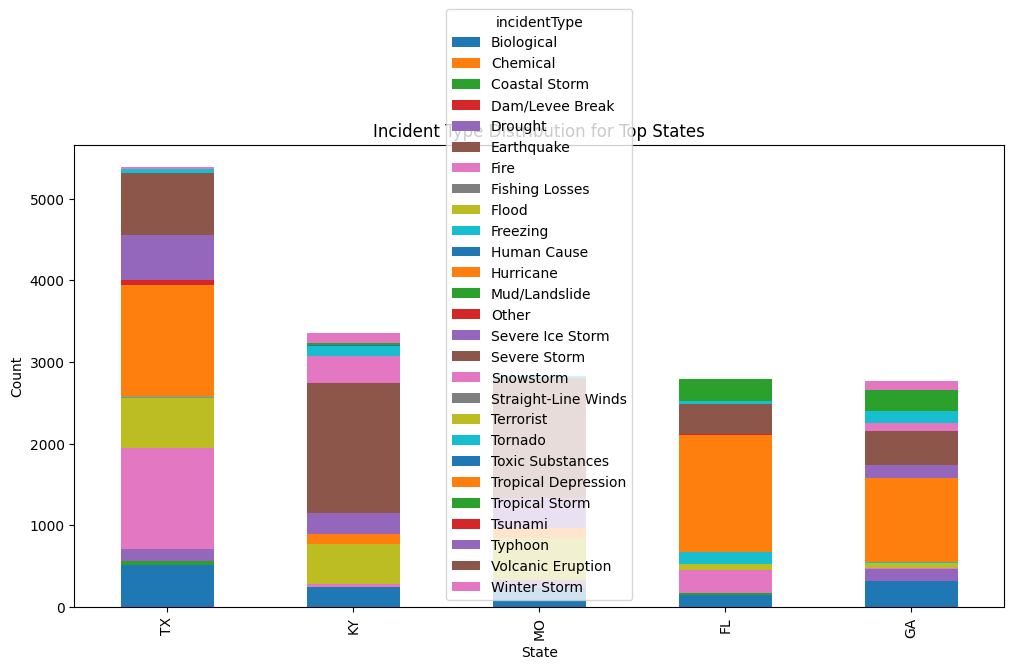

In [13]:
state_incident.loc[state_counts.head(5).index].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Incident Type Distribution for Top States")
plt.xlabel("State")
plt.ylabel("Count")

plt.show()

Insight:

Observation:
The stacked chart shows how different disaster types contribute per state.

Pattern:
Storms dominate most states, while fires are more common in California.

Reason:
Geographical conditions influence disaster types in each region.

Step - 8: Hotspot Map for Specific Disaster

In [14]:
flood_df = df[df['incidentType'] == 'Flood']

flood_counts = flood_df['state'].value_counts().reset_index()
flood_counts.columns = ['state', 'count']

fig = px.choropleth(
    flood_counts,
    locations='state',
    locationmode="USA-states",
    color='count',
    scope="usa",
    color_continuous_scale="Blues",
    title="Flood Disaster Hotspots"
)

fig.show()